<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_03/INFO648_LSN3_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 3 - Working with large dissaggreated data.

 To get the individual datat that the BLS uses I had to use https://cps.ipums.org/cps/

Below we see the data from the first class -
2008 Annual Wages (only men in the mid atlantic)
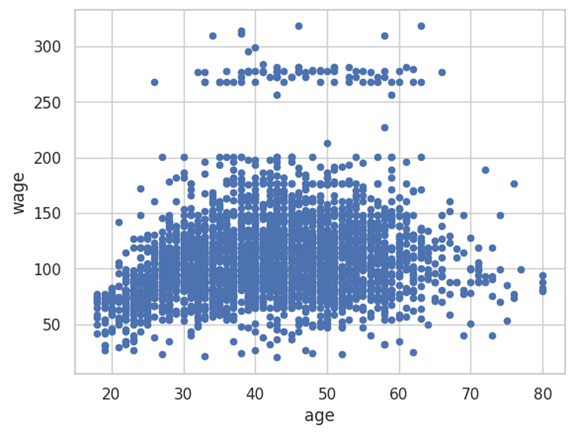

Last class we used the BLS API to pull recent data that covers a much larger portion of the population, but it came as an aggregate (we got the medians for each quarter). This data is aggregated.

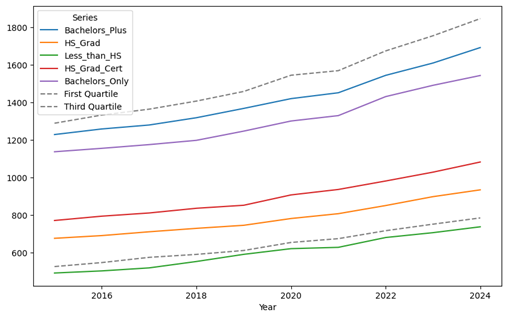

Add in BLS aggregated data


# CPS Data - the individual records that BLS uses for the CPS (Current population survey).

Analytics Objective - understand the risk and reward in working with aggregating and dissagregating data. Also we will see some analytic tools we can use to gain insight and understand some new data structures.

Python Skills- Learn to filter a dataframe, get better with groupby, read a csv., find the mean, median, and count. Continue to learn to plot.

CPS (IPUMS) Data Dictionary

YEAR — Survey year

MONTH — Survey month (1 = Jan, …, 12 = Dec)

SERIAL — Household identifier (unique within year & month)

AGE — Age in years

SEX — Sex (1 = Male, 2 = Female)

OCC — Occupation code (Census 2010-based; use IPUMS crosswalk for labels)

EDUC — Educational attainment (IPUMS coded)

EARNWEEK2 — Weekly earnings from secondary job (USD)

In [1]:
#We need to import pandas
import pandas as pd

A CSV (comma-separated values) file is a simple table where each row is an observation and each column is a variable, used because it’s easy to read, share, and load into tools like Python or Excel for analysis. I used IPUMS but then edited the file to save us some time in class today.


In [2]:
#We need to read in our data to the active python session - we will read it directly into a data frame.
df=pd.read_csv('/content/cps_00007_small_occ.csv')
df.head()

,Unnamed: 0,YEAR,MONTH,SERIAL,AGE,SEX,OCC,EDUC,EARNWEEK2,education,occupation
0,0,2020,1,9,23,2,4720,81,394.0,HS,NaN
1,1,2020,1,14,50,1,9720,73,800.0,HS,NaN
2,2,2020,1,39,22,2,4720,73,360.0,HS,NaN
3,3,2020,1,49,26,2,4110,73,388.0,HS,NaN
4,4,2020,1,62,44,1,4850,73,2260.0,HS,NaN


In [4]:
#what is the dataframe's shape (rows, columns)
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786296 entries, 0 to 786295
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  786296 non-null  int64  
 1   YEAR        786296 non-null  int64  
 2   MONTH       786296 non-null  int64  
 3   SERIAL      786296 non-null  int64  
 4   AGE         786296 non-null  int64  
 5   SEX         786296 non-null  int64  
 6   OCC         786296 non-null  int64  
 7   EDUC        786296 non-null  int64  
 8   EARNWEEK2   786296 non-null  float64
 9   education   786296 non-null  object 
 10  occupation  261220 non-null  object 
dtypes: float64(1), int64(8), object(2)
memory usage: 66.0+ MB


Lets explore the features a bit and see what we have.

In [7]:
#Below are some useful commands to quickly look at our data.
#We need to answer the question - Is it Balanced?
df["YEAR"].unique()
df["occupation"].value_counts()
pd.crosstab(df["education"],df['SEX'])

SEX,1,2
education,,
Bachelors,95337,103960
HS,217684,191783
LessHS,32978,23145
Masters,54933,66476


In [8]:
#Are we missing any data and what types of data do we have?
df=df.fillna('unknown').copy()

,Unnamed: 0,YEAR,MONTH,SERIAL,AGE,SEX,OCC,EDUC,EARNWEEK2,education,occupation
0,0,2020,1,9,23,2,4720,81,394.0,HS,unknown
1,1,2020,1,14,50,1,9720,73,800.0,HS,unknown
2,2,2020,1,39,22,2,4720,73,360.0,HS,unknown
3,3,2020,1,49,26,2,4110,73,388.0,HS,unknown
4,4,2020,1,62,44,1,4850,73,2260.0,HS,unknown
...,...,...,...,...,...,...,...,...,...,...,...
786291,786291,2025,9,68943,42,1,6355,81,1200.0,HS,unknown
786292,786292,2025,9,68943,37,2,5740,111,740.0,Bachelors,unknown
786293,786293,2025,9,68958,40,1,3602,73,1900.0,HS,unknown
786294,786294,2025,9,68958,45,1,3605,81,960.0,HS,unknown


In [9]:
#OK, we are going to be messing with our dataframe a lot, so lets keep 'df"
#prestine and make a new dataframe to work on
df_wage=df.copy()

Let's explore the most recent weekly wages by age (so just the year 2024).
We can subset a dataframe to which ever columns we want by using the dataframe's name and brackets.

so it is like -> subset=dataframe_name[dataframe_name["column1"]==value]
The double == is used here for the conditional because single = is reserved for when we want to assign variables - so == is a check to see if it is the equivelant value.

In [10]:
#Just want 2024 data
new_df=df_wage[df_wage['YEAR']==2024].copy()

<Axes: xlabel='AGE', ylabel='EARNWEEK2'>

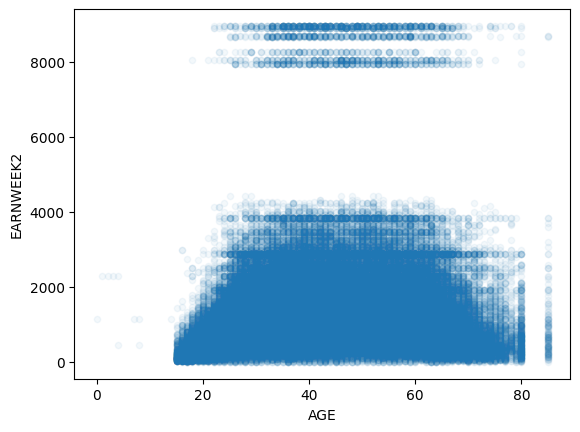

In [12]:
new_df.plot(x='AGE',y='EARNWEEK2',kind='scatter',alpha=.05)

We have a lot of data and to make sense of it we have to look at some forms of aggregation, but being aware that that changes the look and feel of the data.
I want to really explain how we do this - there are a couple of ways.
Here I will introduce the agg method - it is a helper for the groupby.

In [17]:
new_df.groupby("education")["EARNWEEK2"].agg(["mean"]).reset_index()
new_df.groupby("education")["EARNWEEK2"].agg("median").reset_index()

#TOGETHER WE WILL FIND MEAN AND MEDIAN IN THE SAME COMMAND
new_df.groupby("education")["EARNWEEK2"].agg(["median","mean"]).reset_index()
#HOW CAN WE DO THIS BY SUBSETTING
z=new_df[new_df['education']=='HS'].copy()
z['EARNWEEK2'].mean()

np.float64(1005.6459984492425)

<Axes: xlabel='AGE', ylabel='EARNWEEK2'>

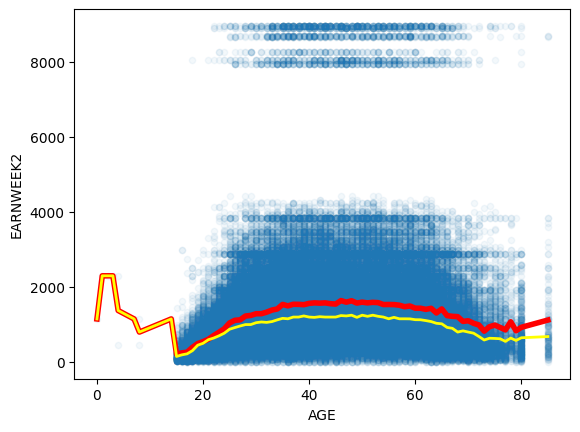

In [21]:
# We already did a lot of the hard work for this
#so I will provide most of the code

mean_by_age = new_df.groupby("AGE")["EARNWEEK2"].mean()
median_by_age = new_df.groupby("AGE")["EARNWEEK2"].median()

new_df.plot.scatter(x="AGE", y="EARNWEEK2", alpha=0.05)

mean_by_age.plot(color="red", linewidth=4)
#PUT MEDIAN LINE IN TOGETHER
median_by_age.plot(color='yellow',linewidth=2)

We have already looked at education and salary in a table form - how would it look as a boxplot.

<Axes: title={'center': 'EARNWEEK2'}, xlabel='education'>

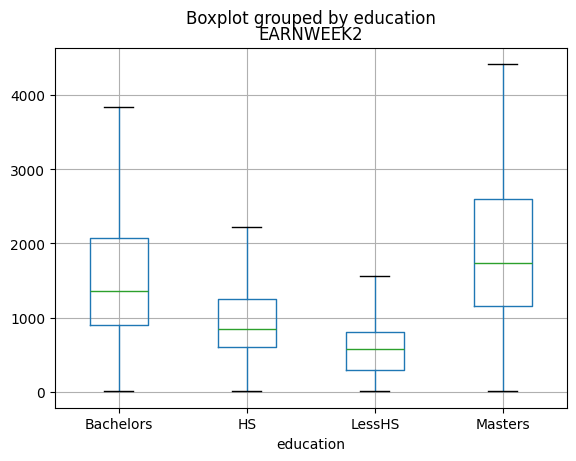

In [24]:
#BOX PLOT WAGE by EDUCATION - SHOWMEANS=TRUE
new_df.boxplot('EARNWEEK2',by='education',showfliers=False)

Let's see if it has changed over time

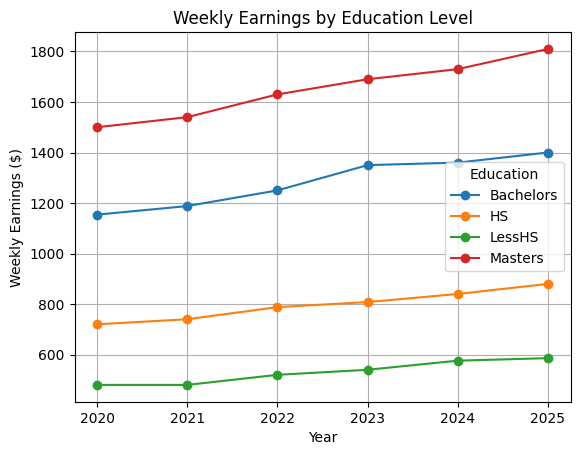

In [25]:
# We made this plot before with the plot command in pandas - matplotlib
#provides more capability - we will introduce it later in more detail

import matplotlib.pyplot as plt

median_by_ed = df_wage.groupby(["education", "YEAR"])["EARNWEEK2"].median().reset_index()

# Pivot to wide format for plotting
plot_df =median_by_ed.pivot(index="YEAR", columns="education", values="EARNWEEK2")

# Plot
plot_df.plot(marker="o")

plt.xlabel("Year")
plt.ylabel("Weekly Earnings ($)")
plt.title("Weekly Earnings by Education Level")
plt.legend(title="Education")
plt.grid(True)

plt.show()


In [ ]:
df_wage.boxplot("EARNWEEK2", by=["education","SEX"], rot=45)

OK, you will have to explore occupations for your homework. Lets look at Operations research analyst and another job or two.

In [33]:
#Here we make a scatter plot for one job and we want to provide a third
#demension of SEX.
#1. Determine the job and set it equal to a variable
#2. Create a subset dataframe
#3. Plot dataframe
job='Operations research analysts'
subset_df=df_wage[df_wage['occupation']==job].copy()


<Axes: title={'center': 'Weekly Earnings for Operations research analysts'}, xlabel='AGE', ylabel='EARNWEEK2'>

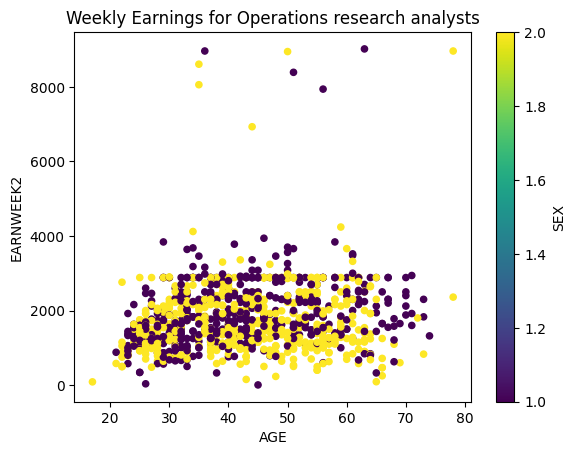

In [37]:
subset_df.plot(
    kind='scatter',
    x='AGE',
    y='EARNWEEK2',
    c='SEX',
    colormap='viridis',
    title=f'Weekly Earnings for {job}'
)

In [40]:
small_df=df_wage[df_wage['occupation'].isin(['Operations research analysts','Lawyers','Tudors'])]

In [41]:
small_df.head(20)

,Unnamed: 0,YEAR,MONTH,SERIAL,AGE,SEX,OCC,EDUC,EARNWEEK2,education,occupation
251,251,2020,1,1604,43,2,2100,125,2220.00,Masters,Lawyers
467,467,2020,1,3025,67,2,2100,124,2500.00,Masters,Lawyers
468,468,2020,1,3025,65,1,2100,60,2780.00,LessHS,Lawyers
520,520,2020,1,3371,62,1,2100,124,2260.00,Masters,Lawyers
597,597,2020,1,3716,35,2,2100,111,866.00,Bachelors,Lawyers
908,908,2020,1,5293,47,2,2100,124,2500.00,Masters,Lawyers
909,909,2020,1,5301,54,2,2100,124,2884.61,Masters,Lawyers
1042,1042,2020,1,5952,32,2,2100,124,2884.61,Masters,Lawyers
1046,1046,2020,1,5996,69,1,2100,123,2140.00,Masters,Lawyers
1081,1081,2020,1,6120,68,1,2100,125,2140.00,Masters,Lawyers


I would like to go back to the discussion about aggregation - we can look at salary over time by gender and education.

In [38]:
# we have been doing a lot of groupbys so I am giving us half the code but this time
trend_df =df_wage.groupby(["YEAR", "education", "SEX"]).agg(mean_earnweek=("EARNWEEK2", "mean")).reset_index()



In [39]:
trend_df.tail()

,YEAR,education,SEX,mean_earnweek
43,2025,HS,2,865.383273
44,2025,LessHS,1,749.514691
45,2025,LessHS,2,491.452866
46,2025,Masters,1,2781.831501
47,2025,Masters,2,1981.675815


In [ ]:
# Split the data by sex
men_df = trend_df[trend_df["SEX"] == 1]
women_df = #We put it in

# Create pivot tables
men_pivot = men_df.pivot(
    index="YEAR",
    columns="education",
    values="mean_earnweek"
)

women_pivot = #We got this




In [ ]:
# we want two plots side by side so we have to use subplots- will cover this more
#later

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

men_pivot.plot(ax=axes[0], marker="o",legend=False)
axes[0].set_title("Weekly Earnings Trends for Men")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Weekly Earnings ($)")
axes[0].grid(True)
#axes[0].legend(title="Education Level")

women_pivot.plot(ax=axes[1], marker="o", legend=False)
axes[1].set_title("Weekly Earnings Trends for Women")
axes[1].set_xlabel("Year")
axes[1].grid(True)
#axes[1].legend(title="Education Level")

fig.suptitle("Weekly Earnings Trends by Education and Gender", fontsize=16)
plt.tight_layout()
plt.show()


If time allows - I want everybody to make a subset dataframe for just 2023 called df_2023

Then find the median salary for school teachers - group by gender and education level (hint - you can make aother sub dataframe if you like).